In [1]:
import numpy as np
import os
import skimage.io
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

fontprops = fm.FontProperties(size=14)
import json
import skimage

In [2]:
toppath = '/mpc/homes/fische_r/nanotom_data/2023_COELY_postmortem'
processing_dict_path = os.path.join(toppath, 'processing_data.json')
processing_dict = json.load(open(processing_dict_path,'r'))

In [48]:
series = 'B'
sample = '6'
stage = 'wet_2'
sample_path = os.path.join(toppath, series+'_series', series+'_'+sample)

In [49]:
path = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_rotcrop.tif')
segpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_BPM_segmented.tif')

In [50]:
im = skimage.io.imread(path)
imseg = skimage.io.imread(segpath)

In [51]:
def extract_membrane_layer_thicknesses(imseg):
    BPM = imseg == 0

    BPMth = BPM.sum(axis=2)

    th = {'BPM': BPMth.mean(), 'BPM_std': BPMth.std()}
    return th

In [7]:
stages = ['dry', 'wet_1', 'wet_2']

In [8]:
th = {}
for stage in stages:
    segpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_BPM_segmented.tif')
    imseg = skimage.io.imread(segpath)
    thst = extract_membrane_layer_thicknesses(imseg)
    th[stage] = thst

In [9]:
th

{'dry': {'BPM': 22.63147142857143, 'BPM_std': 5.067800191399903},
 'wet_1': {'BPM': 25.7572010989011, 'BPM_std': 5.712516170770764},
 'wet_2': {'BPM': 25.432385714285715, 'BPM_std': 5.636145491439612}}

In [10]:
22.6*3

67.80000000000001

In [69]:
25.43*3

76.28999999999999

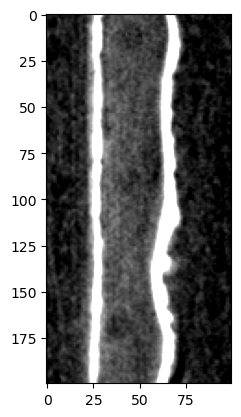

In [52]:
plt.imshow(im[600:800,450,:], 'gray', vmin = 0, vmax=0.35)

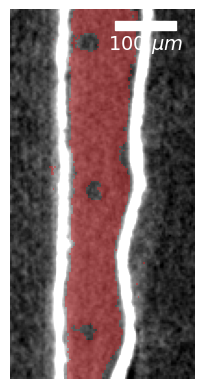

In [58]:
fig, ax = plt.subplots()
# ax[0].imshow(im[600:800,460,:], 'gray')
# ax[0].axis('off')
# scalebar = AnchoredSizeBar(ax[0].transData,
#                            100/3, '100 $\mu m$', 'upper right', 
#                            pad=0.5,
#                            color='white',
#                            frameon=False,
#                            size_vertical=5,
#                            fontproperties=fontprops)
# ax[0].add_artist(scalebar)

ax.imshow(im[600:800,400,:], 'gray', vmin = -0.05, vmax=0.35)
imseg = imseg*1.0
imseg[imseg>0] = np.nan
ax.imshow(imseg[600:800,400,:], cmap = cm.Set1, alpha=0.4, vmin=0, vmax=2,interpolation='none')
ax.axis('off')
scalebar = AnchoredSizeBar(ax.transData,
                           100/3, '100 $\mu m$', 'upper right', 
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=5,
                           fontproperties=fontprops)
ax.add_artist(scalebar)
plotpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'_BPM_seg.png')
plt.savefig(plotpath, bbox_inches='tight')

In [56]:
plotpath

'/mpc/homes/fische_r/nanotom_data/2023_COELY_postmortem/B_series/B_6/B_6_wet_2_BPM.png'

In [59]:
BPM = imseg == 0
BPMth = BPM.sum(axis=2)

In [60]:
BPMth.max()*3

120

(array([2.7100e+02, 2.8500e+02, 3.4800e+02, 4.0600e+02, 5.9500e+02,
        8.7200e+02, 1.3760e+03, 1.9590e+03, 2.5900e+03, 3.3930e+03,
        4.2740e+03, 5.3310e+03, 6.4350e+03, 7.7370e+03, 9.3930e+03,
        1.2149e+04, 1.4735e+04, 1.7839e+04, 2.1858e+04, 2.5482e+04,
        2.9206e+04, 3.2400e+04, 3.6366e+04, 4.1234e+04, 4.7316e+04,
        5.4624e+04, 6.4571e+04, 7.5985e+04, 8.4137e+04, 8.3277e+04,
        7.3273e+04, 5.8643e+04, 4.2847e+04, 2.5645e+04, 1.3098e+04,
        6.0030e+03, 2.6980e+03, 1.0630e+03, 2.5600e+02, 2.2000e+01,
        8.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49.]),
 <BarContainer object of 49 artists>)

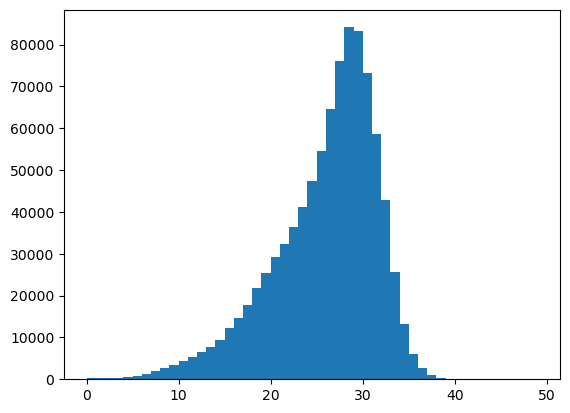

In [61]:
plt.hist(BPMth.flatten(), bins = np.arange(0,50,1))

In [62]:
wet_hist = np.histogram(BPMth.flatten(), bins = np.arange(0,50,1), density=True)

In [45]:
import tikzplotlib

In [46]:
x = np.arange(1,50,1)*3

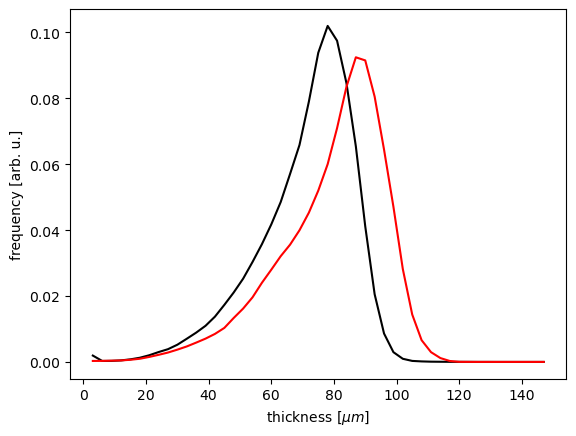

In [64]:
plt.plot(x, dry_hist[0], 'k', label='dry BPM')

plt.plot(x, wet_hist[0], 'r', label='wet BPM')

# plt.legend()
plt.xlabel('thickness [$\mu m$]')
plt.ylabel('frequency [arb. u.]')
plotpath = os.path.join(sample_path, series+'_'+sample+'_'+stage+'BPM_with_CL_th_dist.tex')
tikzplotlib.save(plotpath)

In [65]:
for key in th.keys():
    for key2 in th[key].keys():
        print(key, key2, th[key][key2]*3)

dry BPM 67.89441428571429
dry BPM_std 15.203400574199708
wet_1 BPM 77.27160329670329
wet_1 BPM_std 17.137548512312293
wet_2 BPM 76.29715714285715
wet_2 BPM_std 16.908436474318833


In [67]:
V_wet = BPMth.sum()

In [68]:
V_dry

NameError: name 'V_dry' is not defined

In [78]:
V_wet

26052267

In [97]:
(V_wet_CEM-V_dry_CEM)/V_dry_CEM*100

22.726559774238563

In [83]:
px = 3E-3

In [96]:
(th['wet_2']['CEM']-th['dry']['CEM'])/th['dry']['CEM']*100

25.597356494103785

In [98]:
V

NameError: name 'V' is not defined

In [99]:
V = {}
V['dry'] = {'BPM': V_dry}
V['wet_1'] = {'BPM': V_wet}
V['wet_2_40C'] = {'BPM': V_wet2}

In [100]:
V

{'dry': {'BPM': 23320209, 'AEM': 13916300, 'CEM': 9403909},
 'wet_2': {'BPM': 26052267, 'AEM': 14511173, 'CEM': 11541094}}

In [101]:
th

{'dry': {'AEM': 15.292637362637363,
  'AEM_std': 3.6638358375230635,
  'CEM': 10.333965934065935,
  'CEM_std': 2.8904541159896846,
  'BPM': 25.626603296703298,
  'BPM_std': 4.044966232868214},
 'wet_2': {'AEM': 16.319357849752585,
  'AEM_std': 4.766848801448937,
  'CEM': 12.979188034188034,
  'CEM_std': 3.7092926026961557,
  'BPM': 29.29854588394062,
  'BPM_std': 5.0877801748226945},
 'wet_3': {'AEM': 15.784092486843578,
  'AEM_std': 4.5038124660475685,
  'CEM': 13.604308588064047,
  'CEM_std': 3.502179020106443,
  'BPM': 29.388401074907627,
  'BPM_std': 4.388791829883218}}